In [3]:
pip install tqdm

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import numpy as np
import pandas as pd
import librosa
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

In [ ]:

# ПАРАМЕТРЫ И ПУТИ

SR = 22050
SEGMENT_DURATION = 3
SEGMENT_SAMPLES = SR * SEGMENT_DURATION
N_MFCC = 20
N_FFT = 2048
HOP_LENGTH = 512
NUM_SEGMENTS = 10
TOTAL_SAMPLES = SR * 30

DATA_PATH = r"C:\absolut_slyh\data\combined_genres"        # папка с подпапками жанров
OUTPUT_CSV = r"C:\absolut_slyh\data\features_combined.csv"
MODEL_DIR = r"C:\absolut_slyh\models"

GENRES = ['classical', 'country', 'edm', 'hiphop', 'jazz', 'metal', 'pop', 'rock']
os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:
# ПУТИ
CSV_PATH = r"C:\absolut_slyh\Data\features_combined.csv"
MODEL_DIR = r"C:\absolut_slyh\models"
TEST_DIR = r"C:\absolut_slyh\песни"

os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:

# ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ

def extract_features_segment(y_seg, sr):
    features = {}
    chroma = librosa.feature.chroma_stft(y=y_seg, sr=sr, hop_length=HOP_LENGTH)
    features['chroma_stft_mean'] = np.mean(chroma)
    features['chroma_stft_var'] = np.var(chroma)
    rms = librosa.feature.rms(y=y_seg, hop_length=HOP_LENGTH)
    features['rms_mean'] = np.mean(rms)
    features['rms_var'] = np.var(rms)
    cent = librosa.feature.spectral_centroid(y=y_seg, sr=sr, hop_length=HOP_LENGTH)
    features['spectral_centroid_mean'] = np.mean(cent)
    features['spectral_centroid_var'] = np.var(cent)
    bw = librosa.feature.spectral_bandwidth(y=y_seg, sr=sr, hop_length=HOP_LENGTH)
    features['spectral_bandwidth_mean'] = np.mean(bw)
    features['spectral_bandwidth_var'] = np.var(bw)
    roll = librosa.feature.spectral_rolloff(y=y_seg, sr=sr, hop_length=HOP_LENGTH)
    features['rolloff_mean'] = np.mean(roll)
    features['rolloff_var'] = np.var(roll)
    zcr = librosa.feature.zero_crossing_rate(y=y_seg, hop_length=HOP_LENGTH)
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_var'] = np.var(zcr)
    harmony, perceptr = librosa.effects.hpss(y=y_seg)
    features['harmony_mean'] = np.mean(harmony)
    features['harmony_var'] = np.var(harmony)
    features['perceptr_mean'] = np.mean(perceptr)
    features['perceptr_var'] = np.var(perceptr)
    tempo, _ = librosa.beat.beat_track(y=y_seg, sr=sr, hop_length=HOP_LENGTH)
    features['tempo'] = tempo if isinstance(tempo, float) else tempo[0]
    mfcc = librosa.feature.mfcc(y=y_seg, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mfcc = mfcc.T
    for i in range(N_MFCC):
        features[f'mfcc{i+1}_mean'] = np.mean(mfcc[:, i])
        features[f'mfcc{i+1}_var'] = np.var(mfcc[:, i])
    return features

if not os.path.exists(OUTPUT_CSV):
    print("Извлечение признаков из аудиофайлов...")
    all_rows = []
    for genre in GENRES:
        genre_path = os.path.join(DATA_PATH, genre)
        if not os.path.isdir(genre_path):
            print(f"Папка {genre_path} не найдена, пропускаем")
            continue
        for file in tqdm(os.listdir(genre_path), desc=genre):
            if not file.endswith(('.wav', '.mp3')):
                continue
            file_path = os.path.join(genre_path, file)
            try:
                y, sr = librosa.load(file_path, sr=SR, mono=True)
            except Exception as e:
                print(f"Ошибка загрузки {file_path}: {e}")
                continue
            if len(y) < TOTAL_SAMPLES:
                y = np.pad(y, (0, TOTAL_SAMPLES - len(y)), mode='constant')
            else:
                y = y[:TOTAL_SAMPLES]
            for seg_idx in range(NUM_SEGMENTS):
                start = seg_idx * SEGMENT_SAMPLES
                end = start + SEGMENT_SAMPLES
                y_seg = y[start:end]
                feat = extract_features_segment(y_seg, sr)
                feat['filename'] = f"{os.path.splitext(file)[0]}_{seg_idx}.wav"
                feat['label'] = genre
                all_rows.append(feat)
    df = pd.DataFrame(all_rows)
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"CSV сохранён: {OUTPUT_CSV}")
else:
    print(f"CSV уже существует: {OUTPUT_CSV}")
    df = pd.read_csv(OUTPUT_CSV)

In [ ]:
# ЗАГРУЗКА ДАННЫХ
df = pd.read_csv(CSV_PATH)
print(f"Загружено записей: {len(df)}")
print(f"Колонки: {df.columns.tolist()[:5]} ...")

X = df.drop(columns=['filename', 'label'])
y = df['label']

# Кодирование меток
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Загружено записей: 15990
Колонки: ['chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean'] ...


In [ ]:
# ОБУЧЕНИЕ XGBOOST
model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective='multi:softprob', random_state=42
)
model.fit(X_train_scaled, y_train)

# Предсказание на тесте
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ XGBoost test accuracy: {acc:.4f}")



✅ XGBoost test accuracy: 0.8333



📊 Classification Report (по жанрам):
              precision    recall  f1-score   support

   classical       0.93      0.95      0.94       400
     country       0.70      0.75      0.73       400
         edm       0.85      0.83      0.84       400
      hiphop       0.89      0.89      0.89       400
        jazz       0.86      0.85      0.86       398
       metal       0.92      0.90      0.91       400
         pop       0.77      0.74      0.76       400
        rock       0.76      0.75      0.75       400

    accuracy                           0.83      3198
   macro avg       0.83      0.83      0.83      3198
weighted avg       0.83      0.83      0.83      3198



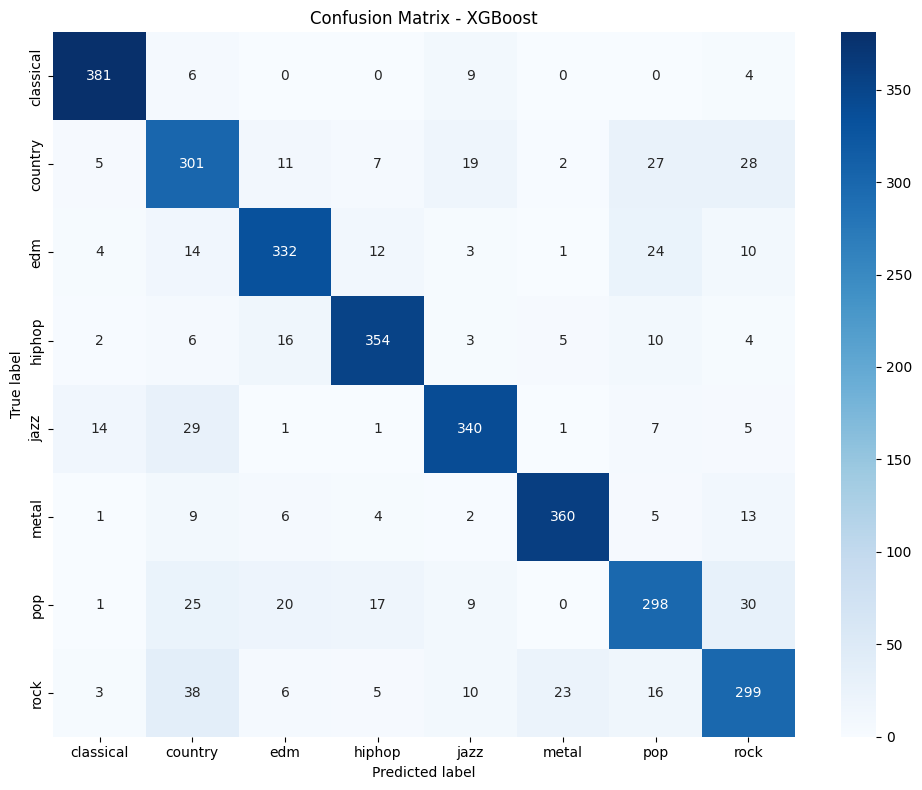


💾 Модель и препроцессоры сохранены в C:\absolut_slyh\models


In [ ]:
# МЕТРИКИ
print("\n📊 Classification Report (по жанрам):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - XGBoost")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("confusion_matrix_xgb.png")
plt.show()

# СОХРАНЕНИЕ МОДЕЛИ 
with open(os.path.join(MODEL_DIR, "xgb_combined.pkl"), "wb") as f:
    pickle.dump(model, f)
with open(os.path.join(MODEL_DIR, "scaler_combined.pkl"), "wb") as f:
    pickle.dump(scaler, f)
with open(os.path.join(MODEL_DIR, "label_encoder_combined.pkl"), "wb") as f:
    pickle.dump(le, f)
print(f"\n💾 Модель и препроцессоры сохранены в {MODEL_DIR}")

# ФУНКЦИЯ ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ 
def extract_features_segment(y_seg, sr):
    features = {}
    chroma = librosa.feature.chroma_stft(y=y_seg, sr=sr, hop_length=HOP_LENGTH)
    features['chroma_stft_mean'] = np.mean(chroma)
    features['chroma_stft_var'] = np.var(chroma)
    rms = librosa.feature.rms(y=y_seg, hop_length=HOP_LENGTH)
    features['rms_mean'] = np.mean(rms)
    features['rms_var'] = np.var(rms)
    cent = librosa.feature.spectral_centroid(y=y_seg, sr=sr, hop_length=HOP_LENGTH)
    features['spectral_centroid_mean'] = np.mean(cent)
    features['spectral_centroid_var'] = np.var(cent)
    bw = librosa.feature.spectral_bandwidth(y=y_seg, sr=sr, hop_length=HOP_LENGTH)
    features['spectral_bandwidth_mean'] = np.mean(bw)
    features['spectral_bandwidth_var'] = np.var(bw)
    roll = librosa.feature.spectral_rolloff(y=y_seg, sr=sr, hop_length=HOP_LENGTH)
    features['rolloff_mean'] = np.mean(roll)
    features['rolloff_var'] = np.var(roll)
    zcr = librosa.feature.zero_crossing_rate(y=y_seg, hop_length=HOP_LENGTH)
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_var'] = np.var(zcr)
    harmony, perceptr = librosa.effects.hpss(y=y_seg)
    features['harmony_mean'] = np.mean(harmony)
    features['harmony_var'] = np.var(harmony)
    features['perceptr_mean'] = np.mean(perceptr)
    features['perceptr_var'] = np.var(perceptr)
    tempo, _ = librosa.beat.beat_track(y=y_seg, sr=sr, hop_length=HOP_LENGTH)
    features['tempo'] = tempo if isinstance(tempo, float) else tempo[0]
    mfcc = librosa.feature.mfcc(y=y_seg, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mfcc = mfcc.T
    for i in range(N_MFCC):
        features[f'mfcc{i+1}_mean'] = np.mean(mfcc[:, i])
        features[f'mfcc{i+1}_var'] = np.var(mfcc[:, i])
    return features

def predict_genre(file_path):
    y, sr = librosa.load(file_path, sr=SR, mono=True)
    if len(y) < TOTAL_SAMPLES:
        y = np.pad(y, (0, TOTAL_SAMPLES - len(y)), mode='constant')
    else:
        start_sample = SR * 30
        if start_sample + TOTAL_SAMPLES <= len(y):
            y = y[start_sample:start_sample+TOTAL_SAMPLES]
        else:
            y = y[-TOTAL_SAMPLES:]
    segment_probs = []
    for seg_idx in range(NUM_SEGMENTS):
        start = seg_idx * SEGMENT_SAMPLES
        end = start + SEGMENT_SAMPLES
        y_seg = y[start:end]
        feat_dict = extract_features_segment(y_seg, sr)
        df_seg = pd.DataFrame([feat_dict])
        X_scaled = scaler.transform(df_seg)
        probs = model.predict_proba(X_scaled)[0]
        segment_probs.append(probs)
    avg_probs = np.mean(segment_probs, axis=0)
    sorted_indices = np.argsort(avg_probs)[::-1]
    top4 = [(le.classes_[i], avg_probs[i]) for i in sorted_indices[:4]]
    return top4


In [ ]:
# ТЕСТ НА ПАПКЕ ПЕСНИ 
if os.path.isdir(TEST_DIR):
    print("\n🎵 Тестирование на реальных треках (папка 'песни'):")
    files = [f for f in os.listdir(TEST_DIR) if f.lower().endswith(('.mp3', '.wav', '.flac'))]
    for file in files:
        file_path = os.path.join(TEST_DIR, file)
        try:
            top4 = predict_genre(file_path)
            print(f"\n{file}")
            for i, (genre, prob) in enumerate(top4, 1):
                print(f"  {i}. {genre}: {prob:.2%}")
        except Exception as e:
            print(f"\n{file}: ошибка - {e}")
else:
    print(f"\nПапка {TEST_DIR} не найдена. Тестирование пропущено.")


🎵 Тестирование на реальных треках (папка 'песни'):

ACDC_-_Back_In_Black_47830042.mp3
  1. rock: 72.16%
  2. hiphop: 8.41%
  3. country: 6.55%
  4. pop: 5.33%

BB_King_-_The_Thrill_Is_Gone_48343628.mp3
  1. country: 40.36%
  2. jazz: 31.31%
  3. rock: 11.52%
  4. pop: 11.13%

Bee_Gees_-_Stayin_Alive_52989254.mp3
  1. rock: 31.25%
  2. pop: 28.93%
  3. country: 17.18%
  4. metal: 13.40%

Bi-2_-_Polkovniku_nikto_ne_pishet_47829792.mp3
  1. metal: 94.80%
  2. rock: 3.58%
  3. pop: 0.81%
  4. edm: 0.29%

Billie_Eilish_-_bad_guy_63132977.mp3
  1. hiphop: 56.17%
  2. edm: 37.02%
  3. pop: 3.21%
  4. country: 1.31%

Dave_Brubeck_-_Take_Five_47937131.mp3
  1. jazz: 94.61%
  2. rock: 4.29%
  3. pop: 0.73%
  4. classical: 0.16%

Dolly_Parton_-_Jolene_48001352.mp3
  1. country: 61.06%
  2. pop: 21.19%
  3. rock: 11.66%
  4. jazz: 4.13%

Drake_-_Gods_Plan_53025361.mp3
  1. hiphop: 96.65%
  2. edm: 1.82%
  3. country: 0.67%
  4. pop: 0.39%

Gloria_Gaynor_-_I_Will_Survive_47841355.mp3
  1. pop: 86.